Defining the domain

In [1]:
 #Defining $\sigma^* $
import numpy as np
import matplotlib.pyplot as plt
import torch

# grid resolution
N = 100

x = np.linspace(-0.5, 0.5, N)
y = np.linspace(-0.5, 0.5, N)
X, Y = np.meshgrid(x, y)

#Defining the domain and bondary


# domain limits
xmin, xmax = -0.5, 0.5
ymin, ymax = -0.5, 0.5

# grid spacing
hx = (xmax - xmin) / (N - 1)
hy = (ymax - ymin) / (N - 1)

# 1D grids
x = np.linspace(xmin, xmax, N)
y = np.linspace(ymin, ymax, N)

# 2D mesh
X, Y = np.meshgrid(x, y)

Defining boundary

In [2]:
# Collect boundary grid points (ordered clockwise, no duplicate corners)
# Domain: square [-0.5, 0.5]^2 with grid spacing hx, hy from (x, y)

boundary_x = []
boundary_y = []

# 1. Bottom edge: left → right (y = ymin)
boundary_x.extend(x)
boundary_y.extend([ymin] * N)

# 2. Right edge: bottom → top (x = xmax), exclude corners already in bottom/top
boundary_x.extend([xmax] * (N - 2))
boundary_y.extend(y[1:-1])

# 3. Top edge: right → left (y = ymax)
boundary_x.extend(x[::-1])
boundary_y.extend([ymax] * N)

# 4. Left edge: top → bottom (x = xmin), exclude corners
boundary_x.extend([xmin] * (N - 2))
boundary_y.extend(y[-2:0:-1])

boundary_x = np.array(boundary_x)
boundary_y = np.array(boundary_y)

m = len(boundary_x)  # total boundary grid points
print("Total boundary points 4N-4:", m)

Total boundary points 4N-4: 396


Defining L-shape sigma

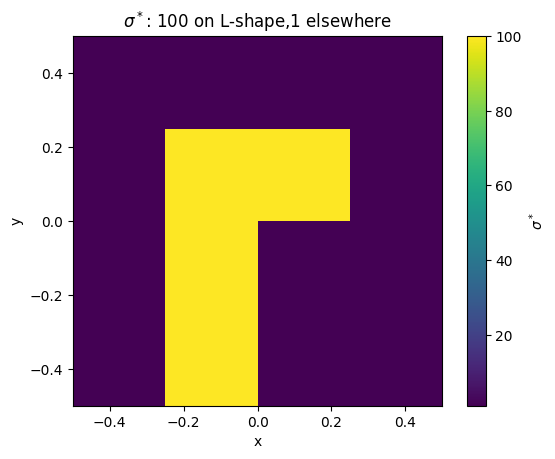

In [3]:
import numpy as np
import matplotlib.pyplot as plt

N = 100

x = np.linspace(-0.5, 0.5, N)
y = np.linspace(-0.5, 0.5, N)
X, Y = np.meshgrid(x, y)

# σ* = 100 on L-shape, 0 elsewhere
def in_L(x, y):
    in_h = (-0.25 <= x) & (x <= 0.25) & (0 <= y) & (y <= 0.25)
    in_v = (-0.25 <= x) & (x <= 0) & (-0.5 <= y) & (y <= 0.25)
    return in_h | in_v

Sigma_star = np.where(in_L(X, Y), 100.0, 1.0)

plt.figure()
plt.imshow(Sigma_star, extent=[xmin, xmax, ymin, ymax], origin='lower')
plt.colorbar(label=r"$\sigma^*$")
plt.xlabel("x")
plt.ylabel("y")
plt.title(r"$\sigma^*$: 100 on L-shape,1 elsewhere")
plt.gca().set_aspect("equal")
plt.show()

Uniform placement of source and censors

In [4]:
# Every boundary grid point is either a source or a receiver; uniform and alternating (source → receiver → source → ...)
# m = 4*N - 4 total boundary points

m = len(boundary_x)  # 4*N - 4

n1_idx = np.arange(0, m, 2)   # sources at even boundary indices
n2_idx = np.arange(1, m, 2)   # receivers at odd boundary indices

n1 = len(n1_idx)
n2 = len(n2_idx)
n1_x = boundary_x[n1_idx]
n1_y = boundary_y[n1_idx]
n2_x = boundary_x[n2_idx]
n2_y = boundary_y[n2_idx]

assert n1 + n2 == m
assert len(np.intersect1d(n1_idx, n2_idx)) == 0

print("Number of sources (n_1):", n1)
print("Number of receivers (n_2):", n2)

Number of sources (n_1): 198
Number of receivers (n_2): 198


In [5]:
# F: n_1 × m — row i is delta at source i (1 at boundary index n1_idx[i])
F = np.zeros((n1, m))
for i in range(n1):
    F[i, n1_idx[i]] = 1.0

# G: n_2 × m — row j is delta at receiver j (1 at boundary index n2_idx[j])
G = np.zeros((n2, m))
for j in range(n2):
    G[j, n2_idx[j]] = 1.0

print("F shape:", F.shape, "  G shape:", G.shape)

F shape: (198, 396)   G shape: (198, 396)


In [6]:
# FEM solver for your setup: L-shaped σ*, boundary m = 4*N-4, F and G (e.g. 12×m)
import numpy as np
import scipy.sparse as sp
import scipy.sparse.linalg as spla

xmin, xmax, ymin, ymax = -0.5, 0.5, -0.5, 0.5
h = (xmax - xmin) / (N - 1)
x = np.linspace(xmin, xmax, N)
y = np.linspace(ymin, ymax, N)
nodes = np.array([(x[i], y[j]) for j in range(N) for i in range(N)])
n_nodes = N * N

def idx(i, j):
    return j * N + i

triangles = []
for j in range(N - 1):
    for i in range(N - 1):
        n1, n2 = idx(i, j), idx(i + 1, j)
        n3, n4 = idx(i, j + 1), idx(i + 1, j + 1)
        triangles.append([n1, n2, n4])
        triangles.append([n1, n4, n3])

A = sp.lil_matrix((n_nodes, n_nodes))
for tri in triangles:
    pts = nodes[tri]
    x0, x1, x2 = pts
    B = np.array([[x1[0]-x0[0], x2[0]-x0[0]], [x1[1]-x0[1], x2[1]-x0[1]]])
    area = abs(np.linalg.det(B)) / 2
    C = np.linalg.inv(B).T
    grads = np.array([[-1, -1], [1, 0], [0, 1]]) @ C
    center = pts.mean(axis=0)
    ic = int(round((center[0] - xmin) / h))
    jc = int(round((center[1] - ymin) / h))
    ic, jc = np.clip(ic, 0, N - 1), np.clip(jc, 0, N - 1)
    sigma = Sigma_star[jc, ic]
    for a in range(3):
        for b in range(3):
            A[tri[a], tri[b]] += sigma * area * np.dot(grads[a], grads[b])
A = A.tocsr()

boundary_ij = (
    [(i, 0) for i in range(N)]
    + [(N - 1, j) for j in range(1, N - 1)]
    + [(i, N - 1) for i in range(N - 1, -1, -1)]
    + [(0, j) for j in range(N - 2, 0, -1)]
)
boundary_dofs = np.array([idx(i, j) for (i, j) in boundary_ij], dtype=np.int64)
m = len(boundary_dofs)  # 4*N - 4
interior = np.array([k for k in range(n_nodes) if k not in set(boundary_dofs)], dtype=np.int64)

Aii = A[interior][:, interior]
Aib = A[interior][:, boundary_dofs]
solve_II = spla.splu(Aii).solve

def solve_one_bc(bc_vals):
    bc_vals = np.asarray(bc_vals, dtype=np.float64).flatten()
    rhs = -Aib @ bc_vals
    uI = solve_II(rhs)
    u = np.zeros(n_nodes)
    u[interior] = uI
    u[boundary_dofs] = bc_vals
    return u.reshape(N, N)

# F, G must be (n1, m) and (n2, m) with m = 4*N-4
assert F.shape[1] == m and G.shape[1] == m, "F and G must have m columns (4*N-4)"
u_L_i_list = [solve_one_bc(F[i, :]) for i in range(F.shape[0])]
v_Lj_list = [solve_one_bc(G[j, :]) for j in range(G.shape[0])]
print("FEM: forward", len(u_L_i_list), "adjoint", len(v_Lj_list))
print(u_L_i_list[0].shape)

/tmp/ipykernel_476864/1739997294.py:54: SparseEfficiencyWarning: splu converted its input to CSC format
  solve_II = spla.splu(Aii).solve


FEM: forward 198 adjoint 198
(100, 100)


In [7]:
n1, n2 = F.shape[0], G.shape[0]
m_grid = N * N
h = (xmax - xmin) / (N - 1)

def grad_2d(u):
    gx = np.zeros_like(u)
    gy = np.zeros_like(u)
    gx[1:-1, :] = (u[2:, :] - u[:-2, :]) / (2 * h)
    gx[0, :] = (u[1, :] - u[0, :]) / h
    gx[-1, :] = (u[-1, :] - u[-2, :]) / h
    gy[:, 1:-1] = (u[:, 2:] - u[:, :-2]) / (2 * h)
    gy[:, 0] = (u[:, 1] - u[:, 0]) / h
    gy[:, -1] = (u[:, -1] - u[:, -2]) / h
    return gx, gy

grad_u_x = np.array([grad_2d(u_L_i_list[i])[0] for i in range(n1)])
grad_u_y = np.array([grad_2d(u_L_i_list[i])[1] for i in range(n1)])
grad_v_x = np.array([grad_2d(v_Lj_list[j])[0] for j in range(n2)])
grad_v_y = np.array([grad_2d(v_Lj_list[j])[1] for j in range(n2)])

A = np.zeros((n1 * n2, m_grid))
for ii in range(N):
    for jj in range(N):
        k = ii * N + jj
        U_at_k = np.stack([grad_u_x[:, ii, jj], grad_u_y[:, ii, jj]], axis=1)
        V_at_k = np.stack([grad_v_x[:, ii, jj], grad_v_y[:, ii, jj]], axis=1)
        A[:, k] = (U_at_k @ V_at_k.T).ravel()
A = A / N

print("A shape:", A.shape)

A shape: (39204, 10000)


## Perturbation: four squares 


2×2 grid of 0.2×0.2 squares covering [-0.4,0]×[-0.4,0].

number of perturbed pixels: 1600
fraction support: 0.16
delta_sigma min/max: 0.0 0.001
Sigma min/max: 1.0 100.0


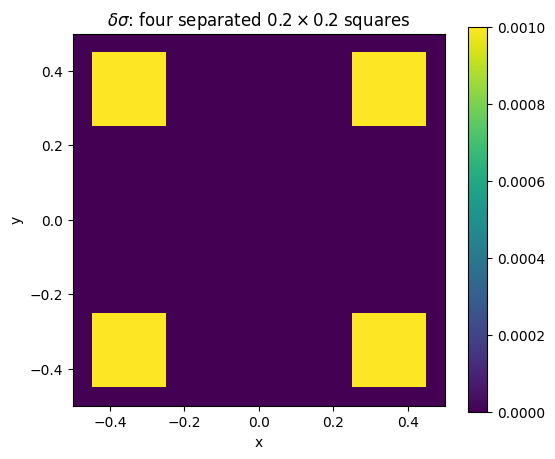

Solved u* count: 198   u count: 198
dn_u_all shape: (198, 396)
dn_u_star_all shape: (198, 396)


In [8]:
import numpy as np
import scipy.sparse as sp
import scipy.sparse.linalg as spla
import matplotlib.pyplot as plt

# ------------------------------------------------------------
# 1) Four separated delta_sigma squares (0.2 x 0.2, amplitude 1e-3)
# ------------------------------------------------------------
xmin, xmax, ymin, ymax = -0.5, 0.5, -0.5, 0.5
h = (xmax - xmin) / (N - 1)

x = np.linspace(xmin, xmax, N)
y = np.linspace(ymin, ymax, N)
X, Y = np.meshgrid(x, y)

delta_sigma_const = 1e-3
square_side = 0.2  # same as original single square

# (x_min, x_max, y_min, y_max) — one square per corner region
squares = [
    (-0.45, -0.25, -0.45, -0.25),  # bottom-left
    ( 0.25,  0.45, -0.45, -0.25),  # bottom-right
    (-0.45, -0.25,  0.25,  0.45),  # top-left
    ( 0.25,  0.45,  0.25,  0.45),  # top-right
]

support = np.zeros_like(X, dtype=bool)
for x0, x1, y0, y1 in squares:
    support |= (X >= x0) & (X <= x1) & (Y >= y0) & (Y <= y1)

delta_sigma = np.where(support, delta_sigma_const, 0.0).astype(np.float64)
Sigma = Sigma_star + delta_sigma

print("number of perturbed pixels:", int(support.sum()))
print("fraction support:", float(np.mean(support)))
print("delta_sigma min/max:", delta_sigma.min(), delta_sigma.max())
print("Sigma min/max:", Sigma.min(), Sigma.max())

fig, ax = plt.subplots(figsize=(6, 5))
im = ax.imshow(delta_sigma, extent=[xmin, xmax, ymin, ymax], origin="lower", cmap="viridis")
ax.set_title(r"$\delta\sigma$: four separated $0.2\times0.2$ squares")
ax.set_xlabel("x")
ax.set_ylabel("y")
ax.set_aspect("equal")
plt.colorbar(im, ax=ax)
plt.show()

# ------------------------------------------------------------
# 2) FEM utilities
# ------------------------------------------------------------
nodes = np.array([(x[i], y[j]) for j in range(N) for i in range(N)])
n_nodes = N * N

def idx(i, j):
    return j * N + i

triangles = []
for j in range(N - 1):
    for i in range(N - 1):
        n1_, n2_ = idx(i, j), idx(i + 1, j)
        n3_, n4_ = idx(i, j + 1), idx(i + 1, j + 1)
        triangles.append([n1_, n2_, n4_])
        triangles.append([n1_, n4_, n3_])

boundary_ij = (
    [(i, 0) for i in range(N)]
    + [(N - 1, j) for j in range(1, N - 1)]
    + [(i, N - 1) for i in range(N - 1, -1, -1)]
    + [(0, j) for j in range(N - 2, 0, -1)]
)
boundary_dofs = np.array([idx(i, j) for (i, j) in boundary_ij], dtype=np.int64)

m_bd = len(boundary_x)
assert len(boundary_dofs) == m_bd
assert F.shape[1] == m_bd and G.shape[1] == m_bd

is_boundary = np.zeros(n_nodes, dtype=bool)
is_boundary[boundary_dofs] = True
interior = np.where(~is_boundary)[0]


def assemble_K_from_sigma(sigma_grid):
    K = sp.lil_matrix((n_nodes, n_nodes))
    for tri in triangles:
        pts = nodes[tri]
        x0, x1, x2 = pts
        B = np.array([
            [x1[0] - x0[0], x2[0] - x0[0]],
            [x1[1] - x0[1], x2[1] - x0[1]],
        ])
        area = abs(np.linalg.det(B)) / 2.0
        C = np.linalg.inv(B).T
        grads = np.array([[-1, -1], [1, 0], [0, 1]]) @ C

        center = pts.mean(axis=0)
        ic = int(round((center[0] - xmin) / h))
        jc = int(round((center[1] - ymin) / h))
        ic = np.clip(ic, 0, N - 1)
        jc = np.clip(jc, 0, N - 1)
        sigma_val = sigma_grid[jc, ic]

        for a in range(3):
            for b_ in range(3):
                K[tri[a], tri[b_]] += sigma_val * area * np.dot(grads[a], grads[b_])
    return K.tocsr()


def solve_all_u_for_sigma(sigma_grid, Fmat):
    K = assemble_K_from_sigma(sigma_grid)
    Aii = K[interior][:, interior]
    Aib = K[interior][:, boundary_dofs]
    solve_II = spla.splu(Aii.tocsc()).solve

    def solve_one_bc(bc_vals):
        bc_vals = np.asarray(bc_vals, dtype=np.float64).flatten()
        rhs = -Aib @ bc_vals
        uI = solve_II(rhs)
        u = np.zeros(n_nodes, dtype=np.float64)
        u[interior] = uI
        u[boundary_dofs] = bc_vals
        return u.reshape(N, N)

    return [solve_one_bc(Fmat[i, :]) for i in range(Fmat.shape[0])]


# ------------------------------------------------------------
# 3) Solve u* and u
# ------------------------------------------------------------
u_star_i_list = solve_all_u_for_sigma(Sigma_star, F)
u_i_list = solve_all_u_for_sigma(Sigma, F)

print("Solved u* count:", len(u_star_i_list), "  u count:", len(u_i_list))


# ------------------------------------------------------------
# 4) Normal derivatives on boundary
# ------------------------------------------------------------
def boundary_dn_u(u):
    q = []
    j = 0
    for i in range(N):
        q.append(-(u[j + 1, i] - u[j, i]) / h)
    i = N - 1
    for j in range(1, N - 1):
        q.append((u[j, i] - u[j, i - 1]) / h)
    j = N - 1
    for i in range(N - 1, -1, -1):
        q.append((u[j, i] - u[j - 1, i]) / h)
    i = 0
    for j in range(N - 2, 0, -1):
        q.append(-(u[j, i + 1] - u[j, i]) / h)
    return np.asarray(q, dtype=np.float64)


dn_u_all = np.array([boundary_dn_u(u) for u in u_i_list])
dn_u_star_all = np.array([boundary_dn_u(u) for u in u_star_i_list])

print("dn_u_all shape:", dn_u_all.shape)
print("dn_u_star_all shape:", dn_u_star_all.shape)

In [9]:
import numpy as np

# boundary sigma in the SAME boundary order:
# bottom -> right -> top(reversed) -> left(reversed)
def sigma_on_boundary(sigma_grid):
    vals = []

    # bottom: j=0, i=0..N-1
    j = 0
    for i in range(N):
        vals.append(sigma_grid[j, i])

    # right: i=N-1, j=1..N-2
    i = N - 1
    for j in range(1, N - 1):
        vals.append(sigma_grid[j, i])

    # top: j=N-1, i=N-1..0
    j = N - 1
    for i in range(N - 1, -1, -1):
        vals.append(sigma_grid[j, i])

    # left: i=0, j=N-2..1
    i = 0
    for j in range(N - 2, 0, -1):
        vals.append(sigma_grid[j, i])

    return np.asarray(vals, dtype=np.float64)

sigma_bd = sigma_on_boundary(Sigma)
sigma_star_bd = sigma_on_boundary(Sigma_star)

# sample at receiver locations (delta g_j)
sigma_recv = sigma_bd[n2_idx]             # (n2,)
sigma_star_recv = sigma_star_bd[n2_idx]   # (n2,)

# LHS data matrix: shape (n1, n2)
LHS_mat = dn_u_all[:, n2_idx] * sigma_recv[None, :] \
        - dn_u_star_all[:, n2_idx] * sigma_star_recv[None, :]

# Optional: uniform boundary spacing ds ≈ h
# LHS_mat = h * LHS_mat

b = LHS_mat.ravel()

print("LHS_mat shape:", LHS_mat.shape)
print("b shape:", b.shape)

LHS_mat shape: (198, 198)
b shape: (39204,)


lambda: 1e-12
||Ax - b|| / ||b||: 0.023241324592319697
||x||: 152.25873823667624


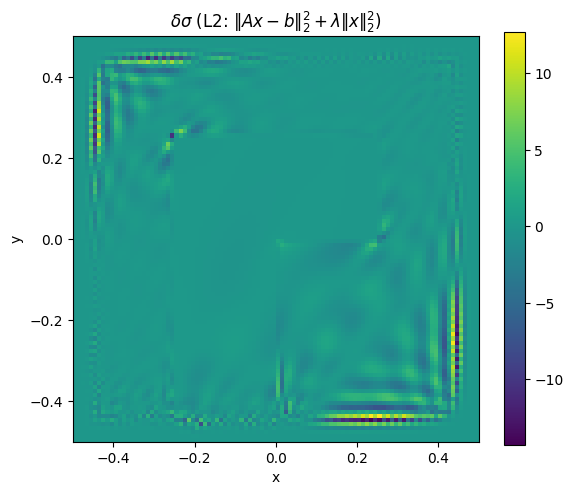

recon min / max: -14.347717891807031 12.69942528193246


In [37]:
import numpy as np
import matplotlib.pyplot as plt

# min ||A x - b||_2^2 + lam * ||x||_2^2
A_mat = np.asarray(A, dtype=np.float64)
b_vec = np.asarray(b, dtype=np.float64).ravel()

m, n = A_mat.shape
assert b_vec.shape[0] == m
assert n == N * N

lam_l2 = 1e-12   # tune: larger -> smoother; smaller -> tighter fit

ATA = A_mat.T @ A_mat
ATb = A_mat.T @ b_vec
x_l2 = np.linalg.solve(ATA + lam_l2 * np.eye(n), ATb)

# diagnostics
res = A_mat @ x_l2 - b_vec
print("lambda:", lam_l2)
print("||Ax - b|| / ||b||:", np.linalg.norm(res) / (np.linalg.norm(b_vec) + 1e-300))
print("||x||:", np.linalg.norm(x_l2))

# reconstruction
delta_sigma_l2 = x_l2.reshape(N, N)

xmin, xmax, ymin, ymax = -0.5, 0.5, -0.5, 0.5
fig, ax = plt.subplots(figsize=(6, 5))
im = ax.imshow(
    delta_sigma_l2,
    extent=[xmin, xmax, ymin, ymax],
    origin="lower",
    aspect="equal",
    cmap="viridis",
)
ax.set_xlabel("x")
ax.set_ylabel("y")
ax.set_title(r"$\delta\sigma$ (L2: $\|Ax-b\|_2^2 + \lambda\|x\|_2^2$)")
plt.colorbar(im, ax=ax)
plt.tight_layout()
plt.show()

print("recon min / max:", float(delta_sigma_l2.min()), float(delta_sigma_l2.max()))

ADMM stopped at max iter 100 CG info: 0
||Ax - b|| / ||b||: 0.28038623775619115
||x||_1: 0.6992725624515059


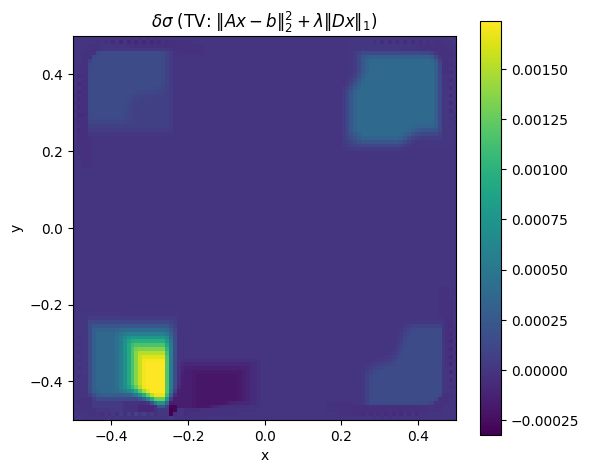

In [12]:
import numpy as np
import matplotlib.pyplot as plt
from scipy import sparse
from scipy.sparse.linalg import LinearOperator, cg

A_mat = np.asarray(A, dtype=np.float64)
b_vec = np.asarray(b, dtype=np.float64).ravel()
m, n = A_mat.shape
assert b_vec.shape[0] == m and n == N * N

Atb = A_mat.T @ b_vec


def make_gradient_operator(N):
    nrow = 2 * N * (N - 1)
    rows = np.empty(2 * nrow, dtype=np.int64)
    cols = np.empty(2 * nrow, dtype=np.int64)
    vals = np.empty(2 * nrow, dtype=np.float64)
    k = 0
    r = 0
    for jj in range(N):
        for ii in range(N - 1):
            k0 = ii * N + jj
            k1 = (ii + 1) * N + jj
            rows[k:k + 2] = r
            cols[k:k + 2] = [k1, k0]
            vals[k:k + 2] = [1.0, -1.0]
            k += 2
            r += 1
    for ii in range(N):
        for jj in range(N - 1):
            k0 = ii * N + jj
            k1 = ii * N + (jj + 1)
            rows[k:k + 2] = r
            cols[k:k + 2] = [k1, k0]
            vals[k:k + 2] = [1.0, -1.0]
            k += 2
            r += 1
    return sparse.csr_matrix((vals, (rows, cols)), shape=(nrow, n))


def soft_threshold(v, kappa):
    return np.sign(v) * np.maximum(np.abs(v) - kappa, 0.0)


# min 0.5||A x - b||^2 + lam_tv * ||D x||_1
lam_tv = 1e-5      # tune: larger -> sparser/smoother; smaller -> closer fit
rho = 1.0
max_admm = 100
tol_admm = 1e-5
cg_tol = 1e-5
cg_maxiter = 150

D = make_gradient_operator(N)
DtD = (D.T @ D).tocsr()

z = np.zeros(D.shape[0])
u = np.zeros_like(z)
x = np.zeros(n)

for it in range(max_admm):
    w = z - u
    rhs = Atb + rho * (D.T @ w)

    def apply_M(v):
        return A_mat.T @ (A_mat @ v) + rho * (DtD @ v)

    Mop = LinearOperator((n, n), matvec=apply_M, dtype=np.float64)
    x, info = cg(Mop, rhs, x0=x, rtol=cg_tol, atol=0.0, maxiter=cg_maxiter)

    Dx = D @ x
    z_old = z.copy()
    z = soft_threshold(Dx + u, lam_tv / rho)
    u = u + Dx - z

    r_primal = np.linalg.norm(Dx - z)
    r_dual = rho * np.linalg.norm(D.T @ (z - z_old))
    if r_primal < tol_admm and r_dual < tol_admm:
        print("ADMM converged at iter", it, "CG info:", info)
        break
else:
    print("ADMM stopped at max iter", max_admm, "CG info:", info)

delta_sigma_tv = x.reshape(N, N)

print("||Ax - b|| / ||b||:",
      np.linalg.norm(A_mat @ x - b_vec) / (np.linalg.norm(b_vec) + 1e-300))
print("||x||_1:", np.linalg.norm(x, ord=1))

# plot
xmin, xmax, ymin, ymax = -0.5, 0.5, -0.5, 0.5
fig, ax = plt.subplots(figsize=(6, 5))
im = ax.imshow(
    delta_sigma_tv,
    extent=[xmin, xmax, ymin, ymax],
    origin="lower",
    aspect="equal",
    cmap="viridis",
)
ax.set_xlabel("x")
ax.set_ylabel("y")
ax.set_title(r"$\delta\sigma$ (TV: $\|Ax-b\|_2^2 + \lambda\|Dx\|_1$)")
plt.colorbar(im, ax=ax)
plt.tight_layout()
plt.show()

In [10]:
import sys
from pathlib import Path

# folder that contains optimize_xi_cond_pytorch.py (same dir as this notebook)
PROJECT_DIR = Path("/home/yaocai/eit").resolve()
if str(PROJECT_DIR) not in sys.path:
    sys.path.insert(0, str(PROJECT_DIR))

import numpy as np
import torch
from optimize_xi_cond_pytorch import optimize_xi_cond, L_from_N

print("python:", sys.executable)
print("torch:", torch.__version__)
print("cuda available:", torch.cuda.is_available())
device = "cuda" if torch.cuda.is_available() else "cpu"

L = L_from_N(N)
A_np = np.asarray(A, dtype=np.float64)
assert A_np.shape == (L * L, N * N), (
    f"Expected A shape ({L*L}, {N*N}) for N={N}, got {A_np.shape}. "
    "Rebuild A from the sensitivity cell (grad u, grad v), not the FEM stiffness."
)

save_prefix = str(PROJECT_DIR / "4square")

xi_opt, history, F_opt, G_opt = optimize_xi_cond(
    A_np,
    c=65,
    N=N,
    steps=200,
    lr=0.1,
    device=device,
    save_prefix=save_prefix,
    return_f_g=True,
)

print("final cond:", history[-1])
print("F_opt shape:", F_opt.shape)
print("G_opt shape:", G_opt.shape)
print("xi_opt shape:", xi_opt.shape)

# Optional explicit check of saved files:
F_saved = np.load(save_prefix + "_F.npy")
G_saved = np.load(save_prefix + "_G.npy")
xi_saved = np.load(save_prefix + "_xi.npy")
print("Saved F shape:", F_saved.shape)
print("Saved G shape:", G_saved.shape)
print("Saved xi shape:", xi_saved.shape)

python: /home/yaocai/miniconda3/envs/eit/bin/python
torch: 2.11.0+cu128
cuda available: True


step    0  cond(ξA) ≈ 6.621630e+11
step   50  cond(ξA) ≈ 1.685809e+11
step  100  cond(ξA) ≈ 1.529992e+11
step  150  cond(ξA) ≈ 1.475468e+11
step  199  cond(ξA) ≈ 1.443220e+11
Saved F to /home/yaocai/eit/4square_F.npy shape: (65, 198)
Saved G to /home/yaocai/eit/4square_G.npy shape: (65, 198)
Saved xi to /home/yaocai/eit/4square_xi.npy shape: (4225, 39204)
final cond: 144321988245.39023
F_opt shape: (65, 198)
G_opt shape: (65, 198)
xi_opt shape: (4225, 39204)
Saved F shape: (65, 198)
Saved G shape: (65, 198)
Saved xi shape: (4225, 39204)


Using. previous. result. as. warm. start. solve. using. TV

warm start from full TV:
  ||x||: 0.001137359843127206
  full ||Ax-b||/||b||: 0.9303178658952186
A_w shape: (1600, 10000)
warm start weighted ||A_w x - b_w||/||b_w||: 0.8543880991499606
iter   0  CG=0  weighted=7.8073e-01  full=8.7665e-01
iter  10  CG=0  weighted=8.5432e-01  full=9.3027e-01
iter  20  CG=0  weighted=8.5439e-01  full=9.3032e-01
iter  30  CG=0  weighted=8.5439e-01  full=9.3032e-01
ADMM converged at iter 39
final weighted rel: 0.8543881062618818
final full rel: 0.9303178714294945


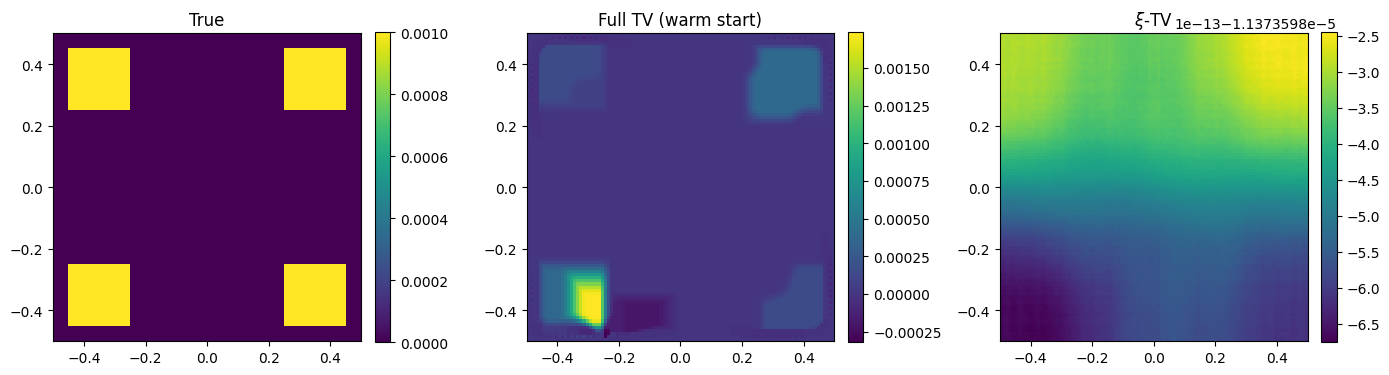

In [ ]:
from pathlib import Path

# --- warm start from full TV (previous cell) ---
x_warm = np.asarray(x, dtype=np.float64).ravel().copy()
# or: x_warm = delta_sigma_tv.ravel().copy()
assert x_warm.shape == (n,)

print("warm start from full TV:")
print("  ||x||:", np.linalg.norm(x_warm))
print("  full ||Ax-b||/||b||:",
      np.linalg.norm(A_mat @ x_warm - b_vec) / (np.linalg.norm(b_vec) + 1e-300))

# --- reduced system ---
save_dir = Path("/home/yaocai/eit")
xi = np.load(save_dir / "4square_xi.npy")

A_w = xi @ A_mat
b_w = xi @ b_vec
Atb_w = A_w.T @ b_w

print("A_w shape:", A_w.shape)
print("warm start weighted ||A_w x - b_w||/||b_w||:",
      np.linalg.norm(A_w @ x_warm - b_w) / (np.linalg.norm(b_w) + 1e-300))

# --- TV on reduced problem, warm start x_warm ---
lam_tv = 1e-3
rho = 1.0
max_admm = 200
min_admm = 40
tol_admm = 1e-5
cg_tol = 1e-7
cg_maxiter = 1000

# reuse D, DtD, soft_threshold, make_gradient_operator from previous cell
# if not in memory, uncomment:
# D = make_gradient_operator(N)
# DtD = (D.T @ D).tocsr()

z = np.zeros(D.shape[0])
u = np.zeros_like(z)
x = x_warm.copy()

for it in range(max_admm):
    w = z - u
    rhs = Atb_w + rho * (D.T @ w)

    def apply_M(v):
        return A_w.T @ (A_w @ v) + rho * (DtD @ v)

    Mop = LinearOperator((n, n), matvec=apply_M, dtype=np.float64)
    x, info = cg(Mop, rhs, x0=x, rtol=cg_tol, atol=0.0, maxiter=cg_maxiter)

    Dx = D @ x
    z_old = z.copy()
    z = soft_threshold(Dx + u, lam_tv / rho)
    u = u + Dx - z

    r_primal = np.linalg.norm(Dx - z)
    r_dual = rho * np.linalg.norm(D.T @ (z - z_old))

    if it % 10 == 0 or it == max_admm - 1:
        rel_w = np.linalg.norm(A_w @ x - b_w) / (np.linalg.norm(b_w) + 1e-300)
        rel_f = np.linalg.norm(A_mat @ x - b_vec) / (np.linalg.norm(b_vec) + 1e-300)
        print(f"iter {it:3d}  CG={info}  weighted={rel_w:.4e}  full={rel_f:.4e}")

    if it + 1 >= min_admm and r_primal < tol_admm and r_dual < tol_admm:
        print("ADMM converged at iter", it)
        break
else:
    print("ADMM stopped at max iter", max_admm)

delta_sigma_tv_xi = x.reshape(N, N)

print("final weighted rel:",
      np.linalg.norm(A_w @ x - b_w) / (np.linalg.norm(b_w) + 1e-300))
print("final full rel:",
      np.linalg.norm(A_mat @ x - b_vec) / (np.linalg.norm(b_vec) + 1e-300))

# plot: true vs full TV warm start vs xi TV
fig, axes = plt.subplots(1, 3, figsize=(14, 4))
for ax, img, title in zip(
    axes,
    [delta_sigma, delta_sigma_tv, delta_sigma_tv_xi],
    [r"True", r"Full TV (warm start)", r"$\xi$-TV"],
):
    ax.imshow(img, extent=[xmin, xmax, ymin, ymax],
              origin="lower", aspect="equal", cmap="viridis")
    ax.set_title(title)
    plt.colorbar(ax.images[0], ax=ax, fraction=0.046, pad=0.04)
plt.tight_layout()
plt.show()

In [ ]:
import torch
import numpy as np

A_np = np.asarray(A, dtype=np.float64)
A_t = torch.tensor(A_np, dtype=torch.float64, device="cuda" if torch.cuda.is_available() else "cpu")

condA = torch.linalg.cond(A_t).item()
print("cond(A):", condA)

cond(A): 1.8762670048272197e+23


Unregulated optimization |xi A x - xi b|

A_w shape: (4225, 10000)
b_w shape: (4225,)
lstsq rank: 4164
weighted ||A_w x - b_w|| / ||b_w||: 0.0016819461904653522
full ||A x - b|| / ||b||: 0.4427137189833155


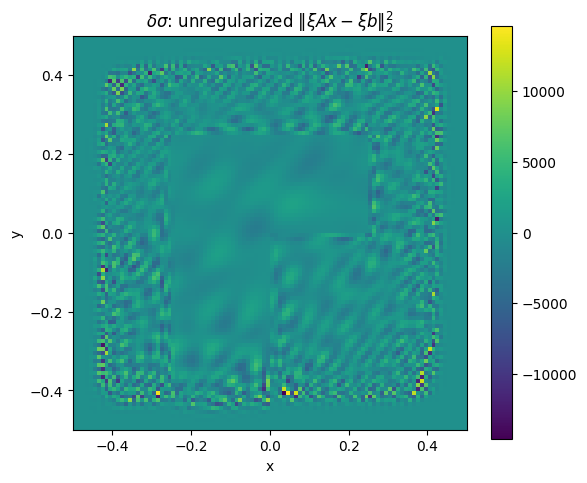

In [19]:
import numpy as np
import matplotlib.pyplot as plt
from pathlib import Path

# load trained xi (and optional F,G)
save_prefix = Path("/home/yaocai/eit/4square")   # or "run1"
xi = np.load(f"{save_prefix}_xi.npy")

A_mat = np.asarray(A, dtype=np.float64)
b_vec = np.asarray(b, dtype=np.float64).ravel()
xi = np.asarray(xi, dtype=np.float64)

L = 2 * N - 2
n = N * N
assert A_mat.shape == (L * L, n)
assert b_vec.shape == (L * L,)
assert xi.shape[1] == L * L

# weighted system
A_w = xi @ A_mat
b_w = xi @ b_vec

print("A_w shape:", A_w.shape)
print("b_w shape:", b_w.shape)

# min ||A_w x - b_w||_2^2  (no regularization)
# underdetermined -> minimum-norm least-squares solution
x_ls, residuals, rank, s = np.linalg.lstsq(A_w, b_w, rcond=None)

print("lstsq rank:", rank)
print("weighted ||A_w x - b_w|| / ||b_w||:",
      np.linalg.norm(A_w @ x_ls - b_w) / (np.linalg.norm(b_w) + 1e-300))
print("full ||A x - b|| / ||b||:",
      np.linalg.norm(A_mat @ x_ls - b_vec) / (np.linalg.norm(b_vec) + 1e-300))

delta_sigma_xi_ls = x_ls.reshape(N, N)

# plot
xmin, xmax, ymin, ymax = -0.5, 0.5, -0.5, 0.5
fig, ax = plt.subplots(figsize=(6, 5))
im = ax.imshow(
    delta_sigma_xi_ls,
    extent=[xmin, xmax, ymin, ymax],
    origin="lower",
    aspect="equal",
    cmap="viridis",
)
ax.set_title(r"$\delta\sigma$: unregularized $\|\xi A x - \xi b\|_2^2$")
ax.set_xlabel("x")
ax.set_ylabel("y")
plt.colorbar(im, ax=ax)
plt.tight_layout()
plt.show()

In [11]:
import numpy as np
import torch

A_mat = np.asarray(A, dtype=np.float64)
xi_t = torch.tensor(xi, dtype=torch.float64, device="cuda" if torch.cuda.is_available() else "cpu")
# --- cond(xi A)  (what optimize_xi_cond minimizes) ---
M = xi @ A_mat
M_t = torch.tensor(M, dtype=torch.float64, device=xi_t.device)
s_M = torch.linalg.svdvals(M_t)
cond_xiA = (s_M[0] / (s_M[-1] + 1e-12)).item()
print("cond(xi @ A):", cond_xiA)
print("M = xi @ A shape:", M.shape)

NameError: name 'xi' is not defined

Total Variation

In [17]:
import numpy as np
import matplotlib.pyplot as plt
from pathlib import Path
from scipy import sparse
from scipy.sparse.linalg import LinearOperator, cg

save_dir = Path("/home/yaocai/eit")
xi = np.load(save_dir / "4square_xi.npy")

A_mat = np.asarray(A, dtype=np.float64)
b_vec = np.asarray(b, dtype=np.float64).ravel()
n = N * N

A_w = xi @ A_mat
b_w = xi @ b_vec
Atb_w = A_w.T @ b_w

# baseline (no TV)
x_ls, *_ = np.linalg.lstsq(A_w, b_w, rcond=None)
rel0 = np.linalg.norm(A_w @ x_ls - b_w) / np.linalg.norm(b_w)
print("unreg weighted rel residual:", rel0)


def make_gradient_operator(N):
    nrow = 2 * N * (N - 1)
    rows, cols, vals = [], [], []
    r = 0
    for jj in range(N):
        for ii in range(N - 1):
            k0, k1 = ii * N + jj, (ii + 1) * N + jj
            rows += [r, r]; cols += [k1, k0]; vals += [1.0, -1.0]; r += 1
    for ii in range(N):
        for jj in range(N - 1):
            k0, k1 = ii * N + jj, ii * N + (jj + 1)
            rows += [r, r]; cols += [k1, k0]; vals += [1.0, -1.0]; r += 1
    return sparse.csr_matrix((vals, (rows, cols)), shape=(nrow, n))

def soft_threshold(v, kappa):
    return np.sign(v) * np.maximum(np.abs(v) - kappa, 0.0)

lam_tv = 1       # decrease for better fit; increase for smoother image
rho = 5.0           # try 1, 5, 10
max_admm = 200
min_admm = 30       # do NOT stop before this
tol_admm = 1e-5
cg_tol = 1e-7
cg_maxiter = 500

D = make_gradient_operator(N)
DtD = (D.T @ D).tocsr()

z = np.zeros(D.shape[0])
u = np.zeros_like(z)
x = x_ls.copy()     # warm start from unregularized LS

for it in range(max_admm):
    w = z - u
    rhs = Atb_w + rho * (D.T @ w)

    def apply_M(v):
        return A_w.T @ (A_w @ v) + rho * (DtD @ v)

    Mop = LinearOperator((n, n), matvec=apply_M, dtype=np.float64)
    x, info = cg(Mop, rhs, x0=x, rtol=cg_tol, atol=0.0, maxiter=cg_maxiter)

    Dx = D @ x
    z_old = z.copy()
    z = soft_threshold(Dx + u, lam_tv / rho)
    u = u + Dx - z

    r_primal = np.linalg.norm(Dx - z)
    r_dual = rho * np.linalg.norm(D.T @ (z - z_old))

    if it % 10 == 0 or it == max_admm - 1:
        rel = np.linalg.norm(A_w @ x - b_w) / np.linalg.norm(b_w)
        print(f"iter {it:3d}  CG info={info}  rel={rel:.4e}  prim={r_primal:.2e}  dual={r_dual:.2e}")

    if it + 1 >= min_admm and r_primal < tol_admm and r_dual < tol_admm:
        print("ADMM converged at iter", it)
        break

delta_sigma_xi_tv = x.reshape(N, N)
print("final weighted rel:", np.linalg.norm(A_w @ x - b_w) / np.linalg.norm(b_w))
print("final full rel:    ", np.linalg.norm(A_mat @ x - b_vec) / np.linalg.norm(b_vec))

unreg weighted rel residual: 0.0016819461904653522
iter   0  CG info=500  rel=8.1515e+00  prim=7.31e-04  dual=0.00e+00


iter  10  CG info=0  rel=8.5434e-01  prim=2.64e-11  dual=0.00e+00
iter  20  CG info=0  rel=8.5434e-01  prim=4.28e-13  dual=0.00e+00
ADMM converged at iter 29
final weighted rel: 0.8543355959614302
final full rel:     0.8993211742503463


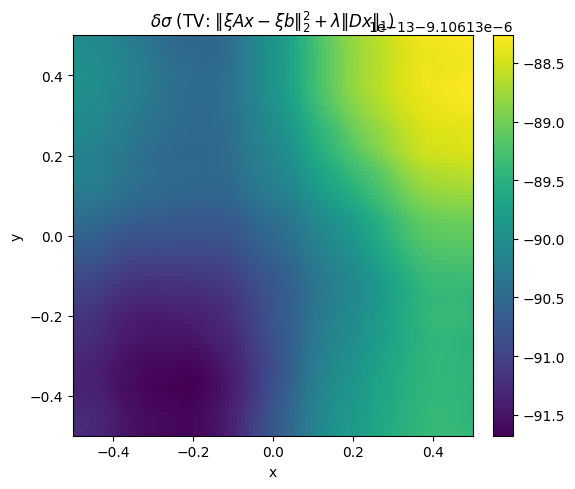

min / max: -9.10613916786132e-06 -9.106138826571314e-06


In [18]:
import matplotlib.pyplot as plt
import numpy as np

xmin, xmax, ymin, ymax = -0.5, 0.5, -0.5, 0.5

# if you only have x:
# delta_sigma_xi_tv = x.reshape(N, N)

fig, ax = plt.subplots(figsize=(6, 5))
im = ax.imshow(
    delta_sigma_xi_tv,
    extent=[xmin, xmax, ymin, ymax],
    origin="lower",
    aspect="equal",
    cmap="viridis",
)
ax.set_xlabel("x")
ax.set_ylabel("y")
ax.set_title(r"$\delta\sigma$ (TV: $\|\xi A x - \xi b\|_2^2 + \lambda\|Dx\|_1$)")
plt.colorbar(im, ax=ax, fraction=0.046, pad=0.04)
plt.tight_layout()
plt.show()

print("min / max:", float(delta_sigma_xi_tv.min()), float(delta_sigma_xi_tv.max()))

Lasso

In [21]:
print(np.shape(A_w))

(4225, 10000)


FISTA converged at iter 8085
lambda_l1: 1e-08
weighted ||A_w x - b_w|| / ||b_w||: 0.5373279573259626
full ||A x - b|| / ||b||: 0.6052013942942245
||x||_1: 0.010926763137532191
nonzeros: 474


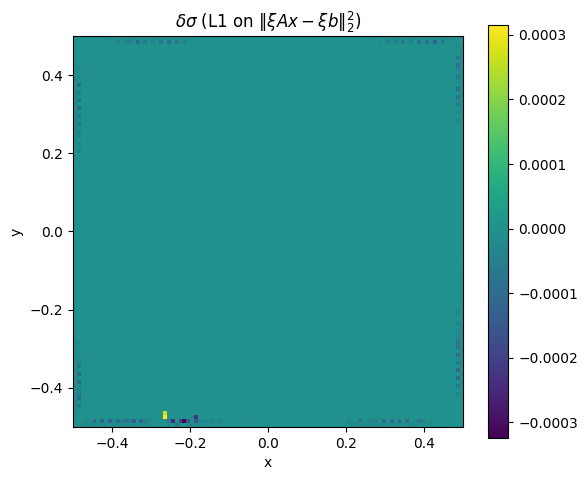

recon min / max: -0.00032439015697422006 0.0003153250698253876


In [20]:
import numpy as np
import matplotlib.pyplot as plt
from pathlib import Path

# --- load xi ---
save_dir = Path("/home/yaocai/eit")
xi = np.load(save_dir / "4square_xi.npy")

A_mat = np.asarray(A, dtype=np.float64)
b_vec = np.asarray(b, dtype=np.float64).ravel()


# reduced system
A_w = xi @ A_mat
b_w = xi @ b_vec


def soft_threshold(x, t):
    return np.sign(x) * np.maximum(np.abs(x) - t, 0.0)


def lasso_fista(A, b, lambda_l1, max_iter=10000, tol=1e-6, verbose=False):
    """min 0.5||Ax - b||^2 + lambda_l1 * ||x||_1"""
    A = np.asarray(A, dtype=np.float64)
    b = np.asarray(b, dtype=np.float64).ravel()
    m, n = A.shape
    s_max = np.linalg.svd(A, compute_uv=False)[0]
    L_lip = float(s_max ** 2) or 1.0
    step = 1.0 / L_lip

    x = np.zeros(n)
    y = x.copy()
    t = 1.0
    for it in range(max_iter):
        grad = A.T @ (A @ y - b)
        x_new = soft_threshold(y - step * grad, lambda_l1 * step)
        t_new = 0.5 * (1.0 + np.sqrt(1.0 + 4.0 * t * t))
        y = x_new + ((t - 1.0) / t_new) * (x_new - x)
        if np.linalg.norm(x_new - x) < tol * (np.linalg.norm(x_new) + 1e-12):
            if verbose:
                print("FISTA converged at iter", it + 1)
            break
        x, t = x_new, t_new
    return x


# --- Lasso on reduced system: min ||A_w x - b_w||^2 + lambda ||x||_1 ---
lambda_l1 = 1e-8   # tune: 1e-8 .. 1e-3
x_l1 = lasso_fista(A_w, b_w, lambda_l1, verbose=True)

res_w = A_w @ x_l1 - b_w
res_full = A_mat @ x_l1 - b_vec

print("lambda_l1:", lambda_l1)
print("weighted ||A_w x - b_w|| / ||b_w||:",
      np.linalg.norm(res_w) / (np.linalg.norm(b_w) + 1e-300))
print("full ||A x - b|| / ||b||:",
      np.linalg.norm(res_full) / (np.linalg.norm(b_vec) + 1e-300))
print("||x||_1:", np.linalg.norm(x_l1, ord=1))
print("nonzeros:", np.sum(np.abs(x_l1) > 1e-10))

delta_sigma_l1_xi = x_l1.reshape(N, N)

# --- plot ---
xmin, xmax, ymin, ymax = -0.5, 0.5, -0.5, 0.5
fig, ax = plt.subplots(figsize=(6, 5))
im = ax.imshow(
    delta_sigma_l1_xi,
    extent=[xmin, xmax, ymin, ymax],
    origin="lower",
    aspect="equal",
    cmap="viridis",
)
ax.set_xlabel("x")
ax.set_ylabel("y")
ax.set_title(r"$\delta\sigma$ (L1 on $\|\xi A x - \xi b\|_2^2$)")
plt.colorbar(im, ax=ax)
plt.tight_layout()
plt.show()

print("recon min / max:", float(delta_sigma_l1_xi.min()), float(delta_sigma_l1_xi.max()))